In all examples, I commonly use a widely used CartPole environment version 1.

See below for the specification of this environment (```CartPole-v1```) - such as, actions, states (observations), and rewards.

**Action Space** - Type : ```Discrete(2)```

- ```0``` : Push cart to the left
- ```1``` : Push cart to the right

**Observation Space** - Type : ```Box(-num, num, (4,), float32)```

- Cart Position ```(-4.8, 4.8)```
- Cart Velocity ```(-inf, inf)```
- Pole Angle ```(-0.41, 0.41)```
- Pole Velocity At Tip ```(-inf, inf)```

**Reward** - Type : ```float32```

It always returns ```1.0``` as reward.<br>
If completely succeeded, you can then take max ```500.0``` rewards in a single episode, because a single episode will be truncated on max ```500``` actions.

**Done Flag (Termination and Truncation)** - Type : ```bool```

It returns the following 2 types of done flag, which is used to check whether the episode is done or not.

- Termination flag : When the agent fails and cannot work any more, termination flag is ```True```, otherwise ```False```.
- Truncation flag : When the agent reaches to max 500 actions (successful at final action), truncation flag is ```True```, otherwise ```False```. (The agent cannot work any more, also in this case.)

**Sample Code to run CartPole**

Here is the sample source code to run CartPole agent.

<ins>source code (Python)</ins>
 

In [3]:
import gymnasium as gym
import random

def pick_sample():
  return random.randint(0, 1)

env = gym.make("CartPole-v1")

for i in range(1):
  print("start episode {}".format(i))
  done = False
  s, _ = env.reset()
  print("initial state: {}, {}, {}, {}".format(s[0], s[1], s[2], s[3]))
  while not done:
    a = pick_sample()
    s, r, term, trunc, _ = env.step(a)
    done = term or trunc
    print("action: {},  reward: {}".format(a, r))
    print("state: {}, {}, {}, {}".format(s[0], s[1], s[2], s[3]))
env.close()

start episode 0
initial state: 0.007182032335549593, 0.0026215142570436, 0.011326786130666733, -0.0021502994932234287
action: 0,  reward: 1.0
state: 0.0072344630025327206, -0.19266103208065033, 0.011283780448138714, 0.29408472776412964
action: 1,  reward: 1.0
state: 0.0033812422771006823, 0.002298242412507534, 0.017165474593639374, 0.004981799982488155
action: 1,  reward: 1.0
state: 0.0034272070042788982, 0.19716987013816833, 0.017265111207962036, -0.28223615884780884
action: 1,  reward: 1.0
state: 0.0073706042021512985, 0.3920413553714752, 0.011620387434959412, -0.5694241523742676
action: 0,  reward: 1.0
state: 0.015211431309580803, 0.19675835967063904, 0.00023190479259938002, -0.27310311794281006
action: 1,  reward: 1.0
state: 0.019146598875522614, 0.3918769955635071, -0.005230157636106014, -0.5657128691673279
action: 0,  reward: 1.0
state: 0.026984138414263725, 0.19682881236076355, -0.016544414684176445, -0.27468228340148926
action: 0,  reward: 1.0
state: 0.030920714139938354, 0.001

In [ ]:
import math
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1")


new_observation_shape = (20, 20, 20, 20)

bins = []
for i in range(4):
    item = np.linspace(
        env.observation_space.low[i] if (i == 0) or (i == 2) else -4,
        env.observation_space.high[i] if (i == 0) or (i == 2) else 4,
        num=new_observation_shape[i],
        endpoint=False)
    item = np.delete(item, 0)
    bins.append(item)
    print(bins[i])

# define function to convert to discrete state
def get_discrete_state(s):
    new_s = []
    for i in range(4):
        new_s.append(np.digitize(s[i], bins[i]))
    return new_s

[-4.32       -3.8400002  -3.3600001  -2.88       -2.4        -1.9200001
 -1.44       -0.96000004 -0.48000002  0.          0.48000002  0.96000004
  1.44        1.9200001   2.4         2.88        3.3599997   3.8400002
  4.3200006 ]
[-3.6 -3.2 -2.8 -2.4 -2.  -1.6 -1.2 -0.8 -0.4  0.   0.4  0.8  1.2  1.6
  2.   2.4  2.8  3.2  3.6]
[-0.37699112 -0.3351032  -0.29321533 -0.25132743 -0.20943952 -0.16755164
 -0.12566373 -0.08377582 -0.04188791  0.          0.04188788  0.08377576
  0.1256637   0.16755158  0.20943952  0.2513274   0.29321527  0.3351032
  0.3769911 ]
[-3.6 -3.2 -2.8 -2.4 -2.  -1.6 -1.2 -0.8 -0.4  0.   0.4  0.8  1.2  1.6
  2.   2.4  2.8  3.2  3.6]


In [ ]:
q_table = np.zeros(new_observation_shape + (env.action_space.n,))
q_table.shape


(20, 20, 20, 20, 2)

In [ ]:
gamma = 0.99
alpha = 0.1
epsilon = 1
epsilon_decay = epsilon / 4000

# pick up action from q-table with greedy exploration
def pick_sample(s, epsilon):
    # get optimal action,
    # but with greedy exploration (to prevent picking up same values in the first stage)
    if np.random.random() > epsilon:
        a = np.argmax(q_table[tuple(s)])
    else:
        a = np.random.randint(0, env.action_space.n)
    return a

env = gym.make("CartPole-v1")
reward_records = []
for i in range(6000):
    # Run episode till done
    done = False
    total_reward = 0
    s, _ = env.reset()
    s_dis = get_discrete_state(s)
    while not done:
        a = pick_sample(s_dis, epsilon)
        s, r, term, trunc, _ = env.step(a)
        done = term or trunc
        
        s_dis_next = get_discrete_state(s)

        # Update Q-Table
        maxQ = np.max(q_table[tuple(s_dis_next)])
        q_table[tuple(s_dis)][a] += alpha * (r + gamma * maxQ - q_table[tuple(s_dis)][a])
                 
        s_dis = s_dis_next
        total_reward += r

    # Update epsilon for each episode
    if epsilon - epsilon_decay >= 0:
        epsilon -= epsilon_decay

    # Record total rewards in episode (max 500)
    print("Run episode{} with rewards {}".format(i, total_reward), end="\r")
    reward_records.append(total_reward)

print("\nDone")
env.close()

Run episode5999 with rewards 500.0
Done


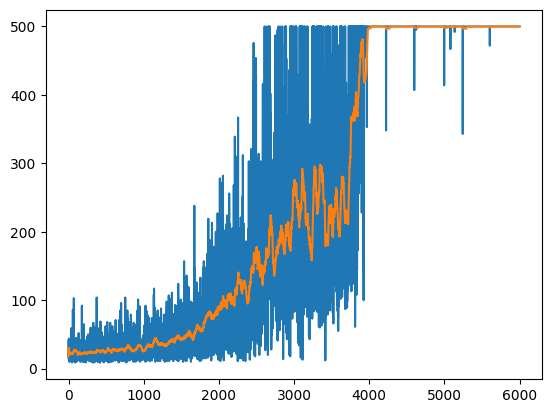

In [ ]:
import matplotlib.pyplot as plt
# Generate recent 50 interval average
average_reward = []
for idx in range(len(reward_records)):
    avg_list = np.empty(shape=(1,), dtype=int)
    if idx < 50:
        avg_list = reward_records[:idx+1]
    else:
        avg_list = reward_records[idx-49:idx+1]
    average_reward.append(np.average(avg_list))
# Plot
plt.plot(reward_records)
plt.plot(average_reward)